<a href="https://colab.research.google.com/github/Abhijith526/machine-learning/blob/main/MLlab_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#A1

from google.colab import files
uploaded = files.upload()

Saving Lab Session Data.xlsx to Lab Session Data (1).xlsx


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel("Lab Session Data.xlsx",sheet_name="Purchase data")
df.head()

,Customer,Candies (#),Mangoes (Kg),Milk Packets (#),Payment (Rs),Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Candy,Mango,Milk
0,C_1,20,6,2,386,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,55.0,18.0
1,C_2,16,3,6,289,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C_3,27,6,2,393,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C_4,19,1,2,110,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C_5,24,4,2,280,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
x = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']]
y = df['Payment (Rs)']

In [ ]:
print(x.shape[0])

10


In [ ]:
rank = np.linalg.matrix_rank(x)
print(rank)

3


In [ ]:
x_pinv = np.linalg.pinv(x)
print(x_pinv)

[[-0.01008596 -0.03124505  0.01013951  0.0290728   0.0182907   0.01161794
  -0.00771348  0.00095458  0.01743623 -0.00542016]
 [ 0.09059668  0.07263726  0.03172933 -0.09071908 -0.01893196 -0.06926996
   0.05675464  0.03152577 -0.07641966  0.00357352]
 [ 0.00299878  0.15874243 -0.05795468 -0.06609024 -0.06295043  0.03348017
   0.01541831 -0.01070461  0.00029003  0.05938755]]


In [ ]:
cost = x_pinv @ y
print(cost)

[ 1. 55. 18.]


In [ ]:
#A2

df['class'] = np.where(df['Payment (Rs)'] > 200, 'rich','poor')
y = df['class']
print(y)

0    rich
1    rich
2    rich
3    poor
4    rich
5    poor
6    rich
7    rich
8    poor
9    poor
Name: class, dtype: object


In [ ]:
#A3

di = pd.read_excel("Lab Session Data (1).xlsx",sheet_name="IRCTC Stock Price")

In [ ]:
price = di['Price']
mean = np.mean(price)
Var = np.var(price)
print("Variance:",Var)
print("Mean:",mean)

Variance: 58496.49239931618
Mean: 1560.6634538152612


In [ ]:
def my_mean(data):
  total = 0
  for value  in data:
    total += value
  return total/len(data)

In [ ]:
def my_variance(data):
  mean = my_mean(data)
  total = 0
  for value in data:
    total += (value - mean)**2
  return total/len(data)

In [ ]:
print("My Mean :", my_mean(price))
print("NumPy Mean :", mean)

print("My Variance :", my_variance(price))
print("NumPy Variance :", Var)

My Mean : 1560.6634538152598
NumPy Mean : 1560.6634538152612
My Variance : 58496.49239931618
NumPy Variance : 58496.49239931618


In [ ]:
import time
times = []
for i in range(10):
  start = time.perf_counter()
  my_mean(price)
  end = time.perf_counter()
  times.append(end-start)
avg_my = sum(times)/10
print("average times my_mean:",avg_my)

average times my_mean: 5.291460001899395e-05


In [ ]:
times = []

for i in range(10):
    start = time.perf_counter()
    np.mean(price)
    end = time.perf_counter()
    times.append(end - start)

avg_np = sum(times) / 10
print("Average time (NumPy Mean):", avg_np)

Average time (NumPy Mean): 6.591620003746357e-05


In [ ]:
times = []

for i in range(10):
    start = time.perf_counter()
    my_variance(price)
    end = time.perf_counter()
    times.append(end - start)

avg_var = sum(times) / 10

print("Average time for my_variance:", avg_var)

Average time for my_variance: 8.991710001282627e-05


In [ ]:
import time

times = []
for i in range(10):
    start = time.perf_counter()
    np.var(price)
    end = time.perf_counter()
    times.append(end - start)
avg_npvar = sum(times) / 10

print("Average time (NumPy Variance):", avg_npvar)

Average time (NumPy Variance): 6.551079995915643e-05


In [ ]:
wednesday = di[di['Day']=="Wed"]['Price']
wednesday_mean = np.mean(wednesday)
print('wednesday mean:',wednesday_mean)
print("Population mean:", mean)

wednesday mean: 1550.7060000000001
Population mean: 1560.6634538152612


In [ ]:
april_data = di[di['Month'] == "Apr"]['Price']
april_mean = np.mean(april_data)
print("April mean:", april_mean)
print("Population mean:", mean)

April mean: 1698.9526315789474
Population mean: 1560.6634538152612


In [ ]:
chg = di["Chg%"]
is_loss = lambda x: x < 0
losses = [x for x in chg if is_loss(x)]
prob_loss = len(losses) / len(chg)

print("Probability of making a loss:", prob_loss)

Probability of making a loss: 0.4979919678714859


In [ ]:
wed_chg = di[di["Day"] == "Wed"]["Chg%"]

is_profit = lambda x: x > 0
wed_profits = [x for x in wed_chg if is_profit(x)]

prob_profit_wed = len(wed_profits) / len(wed_chg)

print("Probability of profit on Wednesday:", prob_profit_wed)

Probability of profit on Wednesday: 0.42


In [ ]:
total_days = len(di)
wed_count = len(di[di["Day"] == "Wed"])

profit_and_wed = len(di[(di["Day"] == "Wed") & (di["Chg%"] > 0)])

p_wed = wed_count / total_days
p_profit_and_wed = profit_and_wed / total_days

p_profit_given_wed = p_profit_and_wed / p_wed

print("P(Profit | Wednesday):", p_profit_given_wed)

P(Profit | Wednesday): 0.42


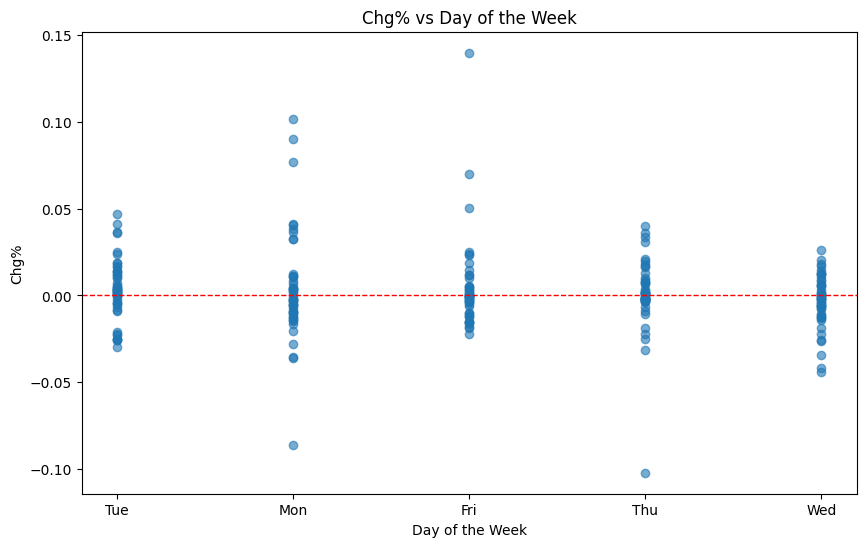

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(di["Day"], di["Chg%"], alpha=0.6)
plt.xlabel("Day of the Week")
plt.ylabel("Chg%")
plt.title("Chg% vs Day of the Week")
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.show()

In [ ]:
#A4

dl = pd.read_excel("Lab Session Data (1).xlsx",sheet_name=2)

In [ ]:
dl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Record ID                  9172 non-null   int64 
 1   age                        9172 non-null   int64 
 2   sex                        9172 non-null   object
 3   on thyroxine               9172 non-null   object
 4   query on thyroxine         9172 non-null   object
 5   on antithyroid medication  9172 non-null   object
 6   sick                       9172 non-null   object
 7   pregnant                   9172 non-null   object
 8   thyroid surgery            9172 non-null   object
 9   I131 treatment             9172 non-null   object
 10  query hypothyroid          9172 non-null   object
 11  query hyperthyroid         9172 non-null   object
 12  lithium                    9172 non-null   object
 13  goitre                     9172 non-null   object
 14  tumor   

In [ ]:
categorical_columns = dl.select_dtypes(include=['object']).columns

numerical_columns = dl.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['sex', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery',
       'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH',
       'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U',
       'FTI measured', 'FTI', 'TBG measured', 'TBG', 'referral source',
       'Condition'],
      dtype='object')

Numerical Columns:
Index(['Record ID', 'age'], dtype='object')


In [ ]:
for column in categorical_columns:
  print("\n",column)
  print(dl[column].unique())


 sex
['F' 'M' '?']

 on thyroxine
['f' 't']

 query on thyroxine
['f' 't']

 on antithyroid medication
['f' 't']

 sick
['f' 't']

 pregnant
['f' 't']

 thyroid surgery
['f' 't']

 I131 treatment
['f' 't']

 query hypothyroid
['t' 'f']

 query hyperthyroid
['f' 't']

 lithium
['f' 't']

 goitre
['f' 't']

 tumor
['f' 't']

 hypopituitary
['f' 't']

 psych
['f' 't']

 TSH measured
['t' 'f']

 TSH
[0.3 1.6 '?' 0.7 1.2 1.9 1 0.5 2.6 68 1.5 5.9 0.05 4 0.4 0.8 0.2 3
 9.599999 140 0.6 1.7 2.5 6.8 2.1 1.1 9.799999 3.7 0.1 0.35 90 1.3 2.7 2.9
 0.25 5.8 2 0.9 3.2 7.4 1.8 5 70 6.5 11.599999 4.2 88 2.2 53 16.5 8.4 4.1
 3.3 80 176 30 11 6 71 9.099999 10.7 4.9 3.4 1.83 4.6 1.4 14 3.5 46 18 170
 19.199999 7.5 145 7.9 19 48 25 7.3 6.7 153 35 3.8 2.3 9.2 12 5.5
 15.299999 0.15 10.299999 430 213 37 216 26 4.3 2.4 47 8.2 14.4 17.4 100
 13.2 41 3.1 22 45 4.5 24 65 4.4 56 11.4 5.2 5.6 8.299999 400 260 5.4 8
 6.6 8.5 5.1 138 42 44 2.8 10 54 3.9 150 31 0.65 200 85 86 6.3 50 34 16
 9.4 14.299999 49 6.2 82 7

In [ ]:
print(dl[numerical_columns].describe())

          Record ID           age
count  9.172000e+03   9172.000000
mean   8.529473e+08     73.555822
std    7.581969e+06   1183.976718
min    8.408010e+08      1.000000
25%    8.504090e+08     37.000000
50%    8.510040e+08     55.000000
75%    8.607110e+08     68.000000
max    8.701190e+08  65526.000000


In [ ]:
print(dl.isnull().sum())

Record ID                    0
age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
TBG measured                 0
TBG                          0
referral source              0
Condition                    0
dtype: int64


In [ ]:
for column in numerical_columns:

    print("\nColumn :",column)

    print("Mean :",dl[column].mean())

    print("Variance :",dl[column].var())

    print("Standard Deviation :",dl[column].std())


Column : Record ID
Mean : 852947346.6122983
Variance : 57486250586150.34
Standard Deviation : 7581968.780346589

Column : age
Mean : 73.55582206716092
Variance : 1401800.8688713463
Standard Deviation : 1183.9767180444667


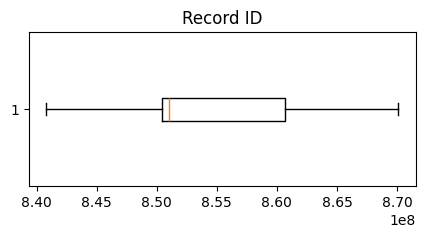

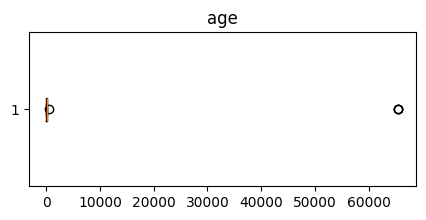

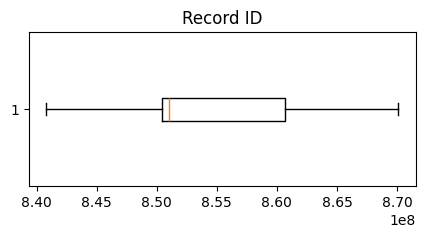

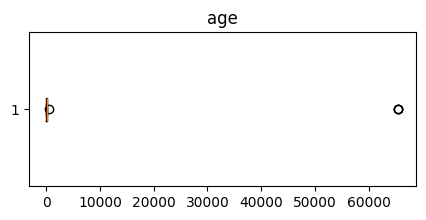

In [ ]:
for column in numerical_columns:

    plt.figure(figsize=(5,2))

    plt.boxplot(dl[column].dropna(),vert=False)

    plt.title(column)

    plt.show()

In [ ]:
#A5

from enum import unique
for col in dl.columns:
  unique_val = dl[col].dropna().unique()
  if len(unique_val) <= 2:
        print(col, ":", unique_val)

on thyroxine : ['f' 't']
query on thyroxine : ['f' 't']
on antithyroid medication : ['f' 't']
sick : ['f' 't']
pregnant : ['f' 't']
thyroid surgery : ['f' 't']
I131 treatment : ['f' 't']
query hypothyroid : ['t' 'f']
query hyperthyroid : ['f' 't']
lithium : ['f' 't']
goitre : ['f' 't']
tumor : ['f' 't']
hypopituitary : ['f' 't']
psych : ['f' 't']
TSH measured : ['t' 'f']
T3 measured : ['f' 't']
TT4 measured : ['f' 't']
T4U measured : ['f' 't']
FTI measured : ['f' 't']
TBG measured : ['f' 't']


In [ ]:
binary_columns = ['on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick',
                   'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid',
                   'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary',
                   'psych']

vec1 = dl.loc[0, binary_columns]
vec2 = dl.loc[1, binary_columns]

print("Vector 1:\n", vec1)
print("\nVector 2:\n", vec2)

Vector 1:
 on thyroxine                 f
query on thyroxine           f
on antithyroid medication    f
sick                         f
pregnant                     f
thyroid surgery              f
I131 treatment               f
query hypothyroid            t
query hyperthyroid           f
lithium                      f
goitre                       f
tumor                        f
hypopituitary                f
psych                        f
Name: 0, dtype: object

Vector 2:
 on thyroxine                 f
query on thyroxine           f
on antithyroid medication    f
sick                         f
pregnant                     f
thyroid surgery              f
I131 treatment               f
query hypothyroid            f
query hyperthyroid           f
lithium                      f
goitre                       f
tumor                        f
hypopituitary                f
psych                        f
Name: 1, dtype: object


In [ ]:
vec1_bin = vec1.map({'t': 1, 'f': 0})
vec2_bin = vec2.map({'t': 1, 'f': 0})

print("Vector 1 (binary):", vec1_bin.tolist())
print("Vector 2 (binary):", vec2_bin.tolist())

Vector 1 (binary): [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Vector 2 (binary): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
f11 = f00 = f01 = f10 = 0

for a, b in zip(vec1_bin, vec2_bin):
    if a == 1 and b == 1:
        f11 += 1
    elif a == 0 and b == 0:
        f00 += 1
    elif a == 0 and b == 1:
        f01 += 1
    elif a == 1 and b == 0:
        f10 += 1

print("f11 =", f11)
print("f00 =", f00)
print("f01 =", f01)
print("f10 =", f10)

f11 = 0
f00 = 13
f01 = 0
f10 = 1


In [ ]:
JC = f11 / (f01 + f10 + f11)
SMC = (f11 + f00) / (f00 + f01 + f10 + f11)

print("Jaccard Coefficient (JC):", JC)
print("Simple Matching Coefficient (SMC):", SMC)

Jaccard Coefficient (JC): 0.0
Simple Matching Coefficient (SMC): 0.9285714285714286


In [ ]:
#A6
from sklearn.preprocessing import LabelEncoder

dl.replace('?', np.nan, inplace=True)
dl.fillna("Missing", inplace=True)

le = LabelEncoder()

for col in dl.columns:
    if dl[col].dtype == "object":
        dl[col] = le.fit_transform(dl[col].astype(str))

/tmp/ipykernel_517/2255490042.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dl.replace('?', np.nan, inplace=True)
/tmp/ipykernel_517/2255490042.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Missing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dl.fillna("Missing", inplace=True)


In [ ]:
A = dl.iloc[0].values.astype(float)
B = dl.iloc[1].values.astype(float)

dot_product = np.dot(A, B)

norm_A = np.linalg.norm(A)
norm_B = np.linalg.norm(B)

cosine = dot_product / (norm_A * norm_B)

print("Cosine Similarity =", cosine)

Cosine Similarity = 0.999999999999946


In [ ]:
#A9

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

dl_standardized = dl.copy()

dl_standardized[numeric_cols] = scaler.fit_transform(dl[numeric_cols])

print(dl_standardized.head())

   Record ID       age       sex  on thyroxine  query on thyroxine  \
0  -1.602090 -0.037634 -0.677543     -0.395384           -0.130247   
1  -1.602090 -0.037634 -0.677543     -0.395384           -0.130247   
2  -1.602086 -0.027499 -0.677543     -0.395384           -0.130247   
3  -1.601822 -0.031722 -0.677543     -0.395384           -0.130247   
4  -1.601822 -0.035100 -0.677543     -0.395384           -0.130247   

   on antithyroid medication    sick  pregnant  thyroid surgery  \
0                  -0.113178 -0.1974 -0.108645        -0.121763   
1                  -0.113178 -0.1974 -0.108645        -0.121763   
2                  -0.113178 -0.1974 -0.108645        -0.121763   
3                  -0.113178 -0.1974 -0.108645        -0.121763   
4                  -0.113178 -0.1974 -0.108645        -0.121763   

   I131 treatment  ...  TT4 measured       TT4  T4U measured       T4U  \
0       -0.137009  ...     -4.444224  1.250945     -3.215191  2.697458   
1       -0.137009  ...      